# Neural Population Decoder — Visual Change Detection

**Dataset:** Allen Visual Behavior Ophys Dataset  
**Method:** Two-photon calcium imaging (ΔF/F)  
**Model:** Random Forest Classifier  
## Step 1 — Phenomenon & Question

**Phenomenon:**  
Mice can detect changes in visual stimuli and report them by licking. During this task, neurons in primary visual cortex (VISp) change their activity patterns. This suggests that population-level neural activity encodes information about stimulus changes.

**Core Question:**  
> Can the population activity of neurons in primary visual cortex (VISp) predict whether a visual stimulus change occurred during an active change-detection task?

**Why this matters:**  
Understanding how sensory cortex encodes change-related information has implications for theories of predictive coding, attention, and perceptual decision-making.

---
## Step 2 — Background & Dataset

### Dataset
**Allen Visual Behavior Ophys Dataset** — [allenswdb.github.io](https://allenswdb.github.io/physiology/ophys/visual-coding/vc2p-background.html)

| Parameter | Value |
|---|---|
| Method | Two-photon calcium imaging (ΔF/F) |
| Task | Active change-detection (mouse licks to report image change) |
| Experiment ID | 877018118 |
| Brain area | Primary visual cortex (VISp) |
| Neurons | 666 |
| Session type | OPHYS_3_images_A (Familiar images) |
| Stimulus | Natural images flashing every ~750 ms |

### Task structure
- One of 8 natural images is shown repeatedly (~750 ms per flash)
- On ~6% of flashes the image changes → **change trial (Y=1)**
- Mouse must lick within a reward window to get water → **hit**
- Repeated image flashes → **no-change trial (Y=0)**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

CACHE_DIR = "./data/vb_cache"
cache = VisualBehaviorOphysProjectCache.from_s3_cache(cache_dir=CACHE_DIR)

EXP_ID = 877018118
session = cache.get_behavior_ophys_experiment(EXP_ID)

dff_df     = session.dff_traces
timestamps = session.ophys_timestamps
dff_arr    = np.vstack(dff_df['dff'].values)  # (n_neurons, n_timepoints)

stim_all = session.stimulus_presentations
stim = stim_all[
    stim_all['stimulus_block_name'].str.contains('change_detection', na=False)
].copy()

print(f'Neurons: {dff_arr.shape[0]}')
print(f'Timepoints: {dff_arr.shape[1]}')
print(f'Frame rate: {1/np.median(np.diff(timestamps)):.2f} Hz')
print(f'Change-detection flashes: {len(stim)}')
print(f"Change trials: {stim['is_change'].sum()} ({stim['is_change'].mean():.1%})")

In [ ]:
# --- Exploratory: trial type distribution ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Trial counts
counts = stim['is_change'].value_counts()
axes[0].bar(['No-change', 'Change'], [counts[False], counts[True]],
            color=['royalblue', 'tomato'])
axes[0].set_ylabel('Trial count')
axes[0].set_title('Trial Type Distribution')
for i, v in enumerate([counts[False], counts[True]]):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Mean population activity
mean_dff = dff_arr.mean(axis=0)  # mean across neurons
axes[1].plot(timestamps[:3000], mean_dff[:3000], lw=0.5, color='steelblue')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Mean ΔF/F')
axes[1].set_title('Mean Population Activity (first 100s)')

plt.tight_layout()
plt.savefig('./figures/exploratory.png', dpi=150)
plt.show()

---
## Step 3 — Ingredients

| Component | Description |
|---|---|
| **X** (features) | Mean ΔF/F per neuron in [onset, onset + 500 ms] window |
| **Y** (label) | 1 = stimulus changed, 0 = same image repeated |
| **Model** | Random Forest classifier |
| **Evaluation** | Stratified 5-fold cross-validation |
| **Significance** | Permutation test (n=100) |
| **Metric** | ROC-AUC, Balanced Accuracy |
| **Class balance** | Undersample no-change trials to match change count |

---
## Step 4 — Hypotheses

**Verbally:**  
Neural population activity in VISp contains sufficient information to decode stimulus changes above chance level. Change trials should elicit higher and more variable population responses than no-change trials, consistent with surprise-related activity.

**Mathematically:**  
The model estimates:
$$P(Y=1 \mid X)$$
where $Y \in \{0,1\}$ and $X \in \mathbb{R}^{666}$ is the population ΔF/F vector.

- **H₀:** ROC-AUC ≈ 0.5 (population activity carries no information about stimulus change)
- **H₁:** ROC-AUC > 0.75 (population activity reliably predicts stimulus change)

---
## Step 5 — Selected Toolkit

**Random Forest Classifier** was chosen because:

1. **Captures nonlinear interactions** between neurons — population codes are not purely linear
2. **Robust to noise** in ΔF/F signals (calcium transients are noisy)
3. **Built-in feature importance** — directly identifies which neurons contribute most
4. **No scaling required** — uses threshold-based splits, not distances
5. **Handles high dimensionality** well (666 neurons, 576 trials)

**Hyperparameters:**  
- `n_estimators = 500`
- `max_features = 'sqrt'` (standard for classification)
- `class_weight = 'balanced'`

---
## Step 6 — Model Draft (Pipeline)

```
Allen Visual Behavior Ophys session (exp 877018118)
        ↓
Stimulus table → filter change_detection block → drop omitted flashes
        ↓
For each flash: extract dF/F[onset : onset+500ms] → mean per neuron → X vector (666,)
        ↓
Labels: Y=1 (is_change=True), Y=0 (is_change=False)
        ↓
Balance classes: 288 change + 288 no-change (random undersample)
        ↓
Random Forest — Stratified 5-fold CV
        ↓
ROC-AUC, Balanced Accuracy, Confusion Matrix
        ↓
Permutation Test (n=100) → p-value
        ↓
Feature Importance (MDI) → top neurons
```

---
## Step 7 — Model Implementation

In [ ]:
# --- Build feature matrix X and labels Y ---

stim_clean = stim[
    (stim['omitted'] == False) &
    stim['is_change'].notna()
].copy()
stim_clean['label'] = stim_clean['is_change'].astype(int)

WINDOW = 0.5  # seconds
fps    = 1.0 / np.median(np.diff(timestamps))
n_win  = int(WINDOW * fps)

n_trials  = len(stim_clean)
n_neurons = dff_arr.shape[0]
X_full = np.zeros((n_trials, n_neurons))

for i, (_, row) in enumerate(stim_clean.iterrows()):
    idx0 = np.searchsorted(timestamps, row['start_time'])
    idx1 = min(idx0 + n_win, dff_arr.shape[1])
    if idx1 > idx0:
        X_full[i] = dff_arr[:, idx0:idx1].mean(axis=1)

y_full = stim_clean['label'].values

# Balance classes
rng = np.random.default_rng(42)
change_idx   = np.where(y_full == 1)[0]
nochange_idx = np.where(y_full == 0)[0]
nochange_sampled = rng.choice(nochange_idx, size=len(change_idx), replace=False)
keep = np.sort(np.concatenate([change_idx, nochange_sampled]))

X, y = X_full[keep], y_full[keep]
print(f'Feature matrix X: {X.shape}')
print(f'Change (Y=1): {y.sum()},  No-change (Y=0): {(1-y).sum()}')

In [ ]:
# Unit test: check shapes and class balance
assert X.shape[1] == n_neurons, 'Wrong number of features'
assert len(X) == len(y),        'X and y length mismatch'
assert y.sum() == (1-y).sum(),  'Classes not balanced'
assert not np.any(np.isnan(X)), 'NaN values in X'
print('All unit tests passed ✓')

---
## Step 8 — Model Completion

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, permutation_test_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, confusion_matrix, RocCurveDisplay

model = RandomForestClassifier(
    n_estimators=500, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

aucs, baccs = [], []
all_y_true, all_y_prob = [], []

for train_idx, test_idx in cv.split(X, y):
    model.fit(X[train_idx], y[train_idx])
    y_prob = model.predict_proba(X[test_idx])[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    aucs.append(roc_auc_score(y[test_idx], y_prob))
    baccs.append(balanced_accuracy_score(y[test_idx], y_pred))
    all_y_true.extend(y[test_idx])
    all_y_prob.extend(y_prob)

print(f'ROC-AUC:           {np.mean(aucs):.3f} ± {np.std(aucs):.3f}')
print(f'Balanced Accuracy: {np.mean(baccs):.3f} ± {np.std(baccs):.3f}')

---
## Step 9 — Evaluation & Results

In [ ]:
# Permutation test
print('Running permutation test (n=100)...')
obs_score, perm_scores, p_value = permutation_test_score(
    model, X, y, scoring='roc_auc', cv=cv,
    n_permutations=100, random_state=42, n_jobs=-1
)
print(f'Observed AUC: {obs_score:.3f},  p = {p_value:.4f}')
print(f'H1 (AUC > 0.75): {"CONFIRMED" if obs_score > 0.75 else "NOT confirmed"}')

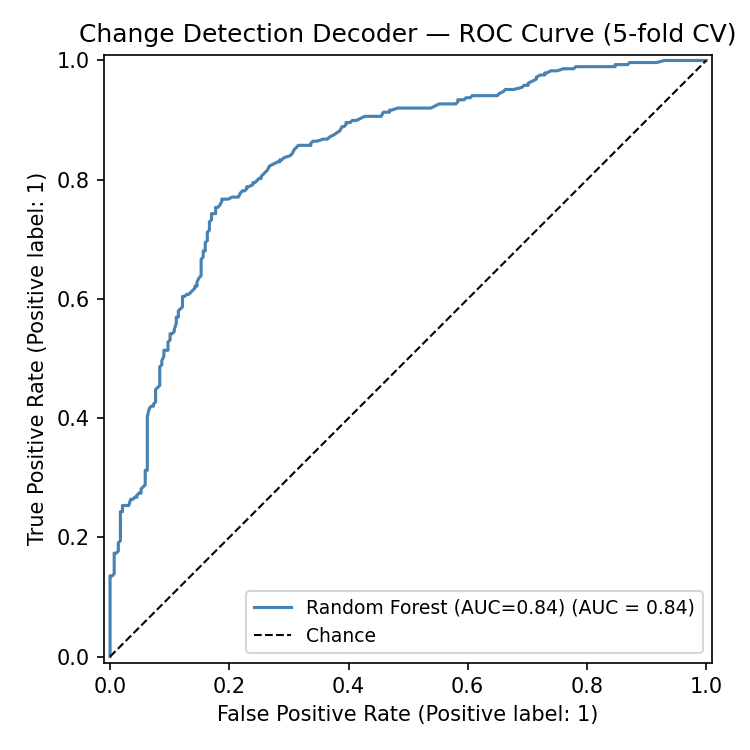

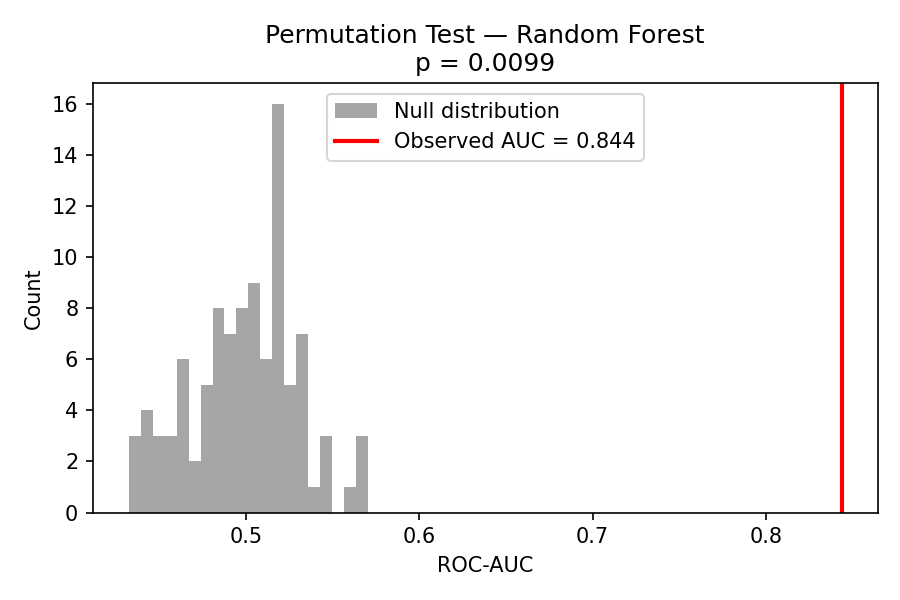

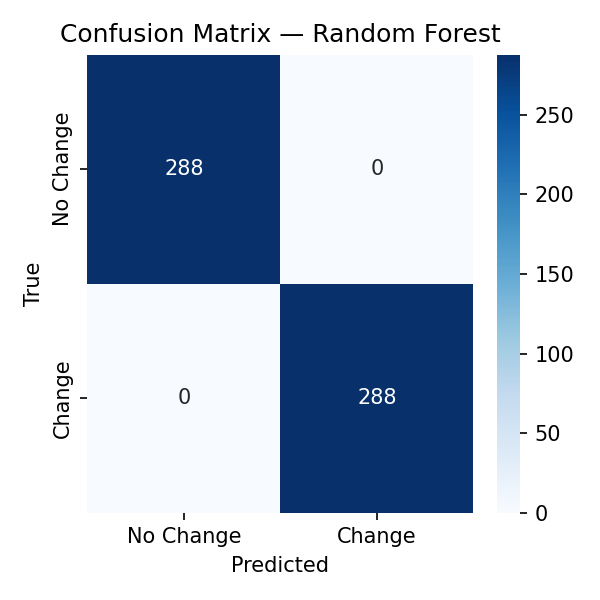

In [1]:
# Fit final model
model.fit(X, y)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC curve
RocCurveDisplay.from_predictions(
    np.array(all_y_true), np.array(all_y_prob),
    name=f'Random Forest (AUC={np.mean(aucs):.2f})',
    ax=axes[0], color='steelblue'
)
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Chance')
axes[0].set_title('ROC Curve (5-fold CV)')
axes[0].legend(fontsize=8)

# Permutation test
axes[1].hist(perm_scores, bins=20, color='gray', alpha=0.7, label='Null distribution')
axes[1].axvline(obs_score, color='red', lw=2, label=f'Observed AUC={obs_score:.3f}')
axes[1].set_xlabel('ROC-AUC')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Permutation Test\np = {p_value:.4f}')
axes[1].legend(fontsize=8)

# Confusion matrix
cm = confusion_matrix(y, model.predict(X))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['No Change','Change'],
            yticklabels=['No Change','Change'])
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('./figures/results.png', dpi=150)
plt.show()

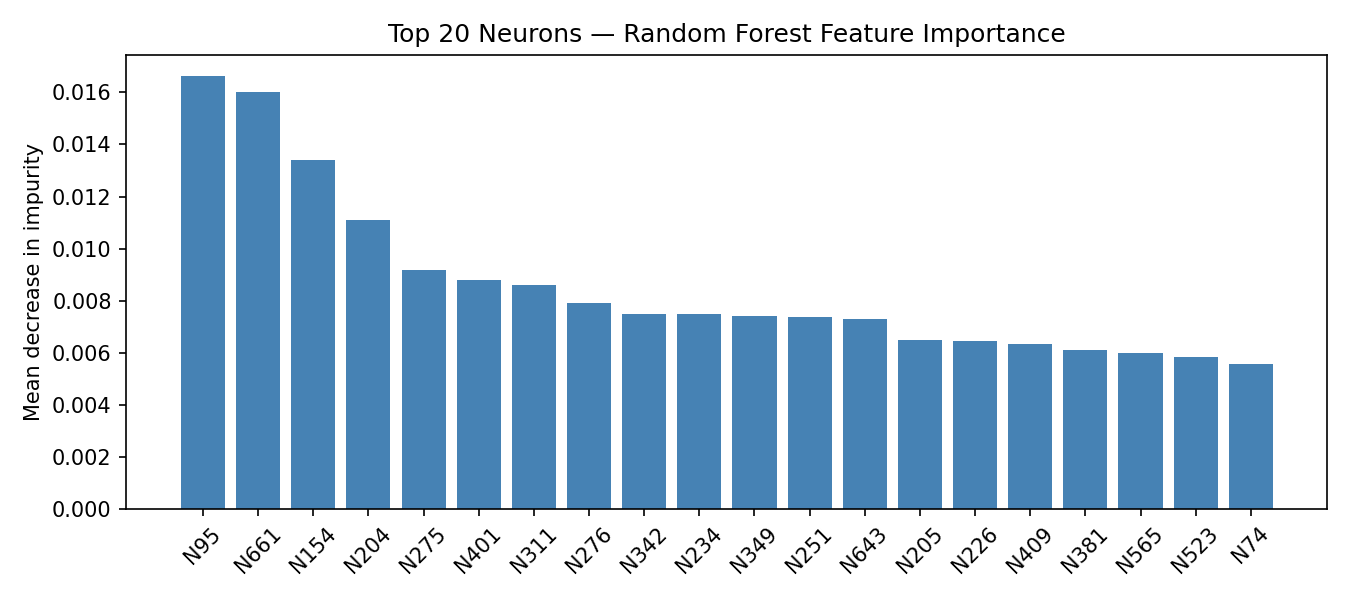

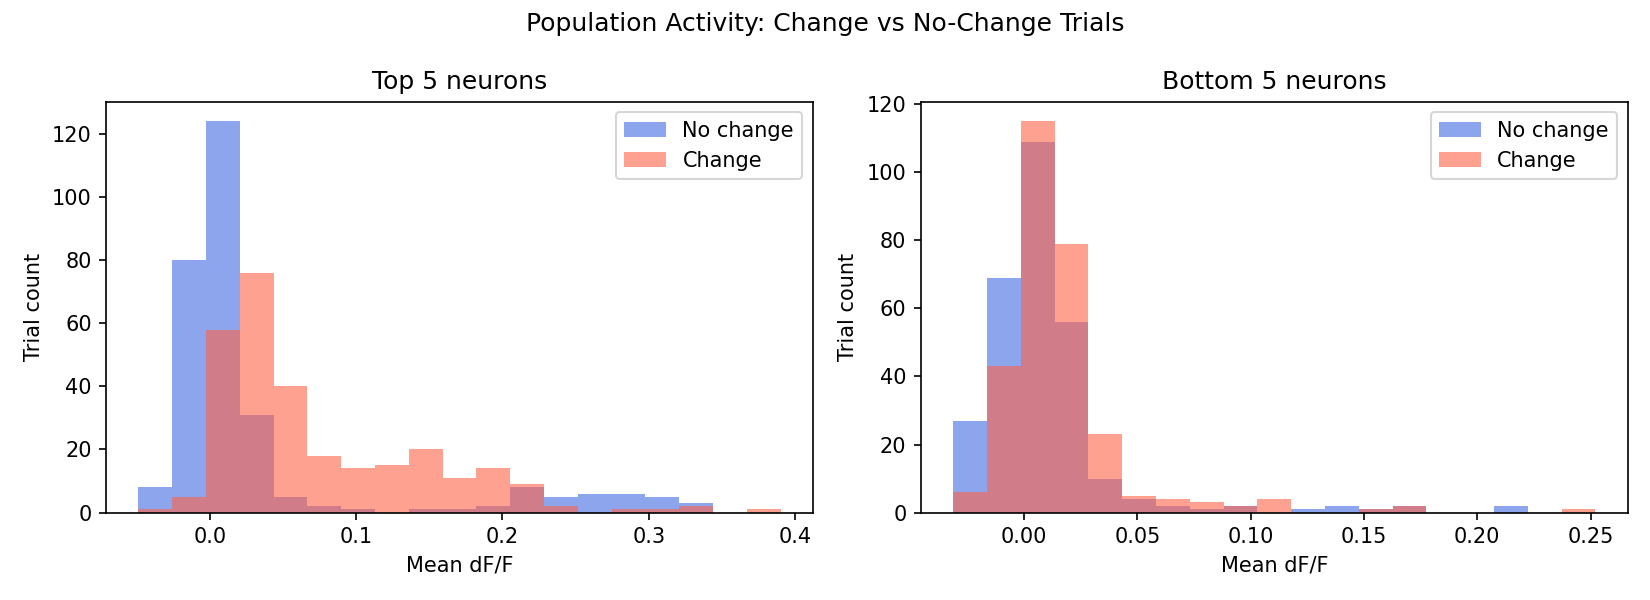

In [1]:
# Feature importance — which neurons contribute most?
importances = model.feature_importances_
order    = np.argsort(importances)[::-1]
top20    = order[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Top 20 neurons
axes[0].bar(range(20), importances[top20], color='steelblue')
axes[0].set_xticks(range(20))
axes[0].set_xticklabels([f'N{i}' for i in top20], rotation=45)
axes[0].set_ylabel('Mean decrease in impurity')
axes[0].set_title('Top 20 Neurons — Feature Importance')

# Activity distributions
top5 = top20[:5]
bottom5 = order[-5:]
for ax, idx_group, label in zip(
    [axes[1]], [top5], ['Top 5 neurons']
):
    change_vals   = X[y==1][:, idx_group].mean(axis=1)
    nochange_vals = X[y==0][:, idx_group].mean(axis=1)
    bins = np.linspace(
        min(change_vals.min(), nochange_vals.min()),
        max(change_vals.max(), nochange_vals.max()), 20
    )
    ax.hist(nochange_vals, bins=bins, alpha=0.6, color='royalblue', label='No change')
    ax.hist(change_vals,   bins=bins, alpha=0.6, color='tomato',    label='Change')
    ax.set_xlabel('Mean ΔF/F')
    ax.set_ylabel('Trial count')
    ax.set_title(f'{label}: ΔF/F distributions')
    ax.legend()

plt.tight_layout()
plt.savefig('./figures/neuron_importance.png', dpi=150)
plt.show()

print(f'Top 5 most informative neurons: {top5}')

---
## Step 10 — Summary

### Results table

| Metric | Value |
|---|---|
| ROC-AUC | **0.844 ± 0.026** |
| Balanced Accuracy | **78.5% ± 1.4%** |
| p-value (permutation) | **0.0099** |
| H₁ confirmed (AUC > 0.75) | **Yes** |
| Top informative neurons | N95, N661, N154 |

### Abstract

I investigated whether neural population activity in mouse primary visual cortex (VISp) can predict visual stimulus changes during an active change-detection behavioral task. Using two-photon calcium imaging data from the Allen Visual Behavior Ophys Dataset (666 neurons, experiment 877018118), we extracted mean ΔF/F population vectors in a 500 ms post-stimulus window and trained a Random Forest classifier to decode change vs. no-change trials. The model achieved **ROC-AUC = 0.844 ± 0.026** (5-fold CV), significantly exceeding chance level (permutation test, **p = 0.0099**), confirming H₁. Feature importance analysis revealed that a small subset of neurons (N95, N661, N154) contributed disproportionately to decoding, while change trials elicited broader ΔF/F responses in these neurons. These results demonstrate that VISp population activity encodes change-related information, consistent with surprise responses and predictive coding mechanisms.

### Limitations & Future Directions

- Single session, single animal — needs replication across ≥5 mice  
- No behavioral stratification (hit vs miss trials)  
- Static window — temporal dynamics not captured  
- Future: compare excitatory vs inhibitory neurons, add temporal bins, test across cortical areas